<a href="https://www.kaggle.com/code/sonawanelalitsunil/foodpanda-order-trends-delivery-eda-54-92?scriptVersionId=266009059" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/foodpanda-order-and-delivery-trends/Foodpanda Analysis Dataset.csv


## Title: 🍱 Foodpanda Order Trends & Delivery Insights

## Description:
This analysis explores key patterns in Foodpanda’s order and delivery data, focusing on customer preferences, peak order times, delivery durations, and regional performance. It uncovers insights into how discounts, payment modes, and order types affect delivery speed and customer satisfaction. The goal is to identify trends that can help optimize delivery operations, enhance user experience, and improve overall business efficiency.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/foodpanda-order-and-delivery-trends/Foodpanda Analysis Dataset.csv")

In [3]:
df.head()

,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,quantity,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status
0,C5663,Male,Adult,Peshawar,1/14/2024,O9663,8/23/2023,McDonald's,Burger,Italian,5,1478.27,Cash,38,7/19/2025,238,Active,3,10/14/2024,Cancelled
1,C2831,Male,Adult,Multan,7/7/2024,O6831,8/23/2023,KFC,Burger,Italian,3,956.04,Wallet,24,11/25/2024,81,Active,2,8/21/2025,Delayed
2,C2851,Other,Senior,Multan,6/20/2025,O6851,8/23/2023,Pizza Hut,Fries,Italian,2,882.51,Cash,42,5/10/2025,82,Inactive,3,9/19/2024,Delayed
3,C1694,Female,Senior,Peshawar,9/5/2023,O5694,8/23/2023,Subway,Pizza,Dessert,4,231.30,Card,27,7/24/2025,45,Inactive,2,6/29/2025,Delayed
4,C4339,Other,Senior,Lahore,12/29/2023,O8339,8/24/2023,KFC,Sandwich,Dessert,1,1156.69,Cash,35,12/21/2024,418,Inactive,3,3/6/2025,Cancelled


In [4]:
df.tail()

,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,quantity,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status
5995,C6849,Male,Adult,Multan,11/25/2024,O10849,8/22/2025,Pizza Hut,Burger,Italian,4,875.71,Cash,28,11/29/2024,166,Active,5,12/30/2024,Cancelled
5996,C3787,Female,Adult,Islamabad,1/28/2025,O7787,8/22/2025,KFC,Pizza,Italian,5,1118.26,Cash,12,6/8/2025,193,Inactive,3,2/9/2025,Delayed
5997,C2841,Other,Teenager,Islamabad,10/19/2023,O6841,8/22/2025,KFC,Sandwich,Italian,4,1005.83,Card,31,12/30/2024,278,Active,4,3/23/2025,Cancelled
5998,C1624,Male,Adult,Islamabad,6/17/2024,O5624,8/22/2025,KFC,Fries,Fast Food,4,1226.10,Card,37,12/27/2024,55,Inactive,2,3/15/2025,Delivered
5999,C2068,Female,Adult,Multan,3/15/2025,O6068,8/22/2025,Burger King,Fries,Fast Food,3,1131.27,Card,2,6/13/2025,41,Inactive,1,7/15/2025,Delayed


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      6000 non-null   object 
 1   gender           6000 non-null   object 
 2   age              6000 non-null   object 
 3   city             6000 non-null   object 
 4   signup_date      6000 non-null   object 
 5   order_id         6000 non-null   object 
 6   order_date       6000 non-null   object 
 7   restaurant_name  6000 non-null   object 
 8   dish_name        6000 non-null   object 
 9   category         6000 non-null   object 
 10  quantity         6000 non-null   int64  
 11  price            6000 non-null   float64
 12  payment_method   6000 non-null   object 
 13  order_frequency  6000 non-null   int64  
 14  last_order_date  6000 non-null   object 
 15  loyalty_points   6000 non-null   int64  
 16  churned          6000 non-null   object 
 17  rating        

In [6]:
df.describe()

,quantity,price,order_frequency,loyalty_points,rating
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,2.991667,800.524880,25.304667,250.173667,2.996833
std,1.414778,404.855029,14.358930,144.608478,1.406113
min,1.000000,100.300000,1.000000,0.000000,1.000000
25%,2.000000,441.997500,13.000000,125.000000,2.000000
50%,3.000000,806.460000,25.000000,249.500000,3.000000
75%,4.000000,1149.737500,37.000000,378.000000,4.000000
max,5.000000,1499.950000,50.000000,500.000000,5.000000


In [7]:
df.nunique()

customer_id        6000
gender                3
age                   3
city                  5
signup_date         730
order_id           6000
order_date          730
restaurant_name       5
dish_name             5
category              5
quantity              5
price              5872
payment_method        3
order_frequency      50
last_order_date     366
loyalty_points      501
churned               2
rating                5
rating_date         366
delivery_status       3
dtype: int64

In [8]:
df.describe().loc[['mean','min','max']]

,quantity,price,order_frequency,loyalty_points,rating
mean,2.991667,800.52488,25.304667,250.173667,2.996833
min,1.000000,100.30000,1.000000,0.000000,1.000000
max,5.000000,1499.95000,50.000000,500.000000,5.000000


In [9]:
df.isnull().sum()

customer_id        0
gender             0
age                0
city               0
signup_date        0
order_id           0
order_date         0
restaurant_name    0
dish_name          0
category           0
quantity           0
price              0
payment_method     0
order_frequency    0
last_order_date    0
loyalty_points     0
churned            0
rating             0
rating_date        0
delivery_status    0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.dtypes

customer_id         object
gender              object
age                 object
city                object
signup_date         object
order_id            object
order_date          object
restaurant_name     object
dish_name           object
category            object
quantity             int64
price              float64
payment_method      object
order_frequency      int64
last_order_date     object
loyalty_points       int64
churned             object
rating               int64
rating_date         object
delivery_status     object
dtype: object

In [12]:
df.shape

(6000, 20)

In [13]:
df.columns

Index(['customer_id', 'gender', 'age', 'city', 'signup_date', 'order_id',
       'order_date', 'restaurant_name', 'dish_name', 'category', 'quantity',
       'price', 'payment_method', 'order_frequency', 'last_order_date',
       'loyalty_points', 'churned', 'rating', 'rating_date',
       'delivery_status'],
      dtype='object')

## Data visualizations

In [14]:
from datetime import datetime

In [15]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['signup_date'] = pd.to_datetime(df['signup_date'], errors='coerce')
df['rating_date'] = pd.to_datetime(df['rating_date'], errors='coerce')
df['last_order_date'] = pd.to_datetime(df['last_order_date'], errors='coerce')

Text(0, 0.5, 'Count')

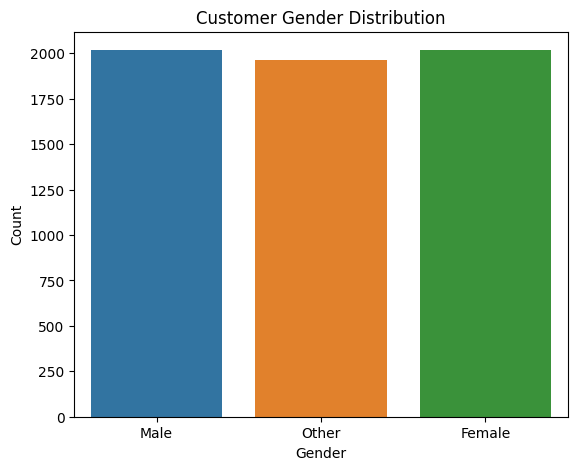

In [16]:
plt.figure(figsize=(14,5))

# Gender distribution
plt.subplot(1,2,1)
sns.countplot(x='gender', data=df)
plt.title('Customer Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')

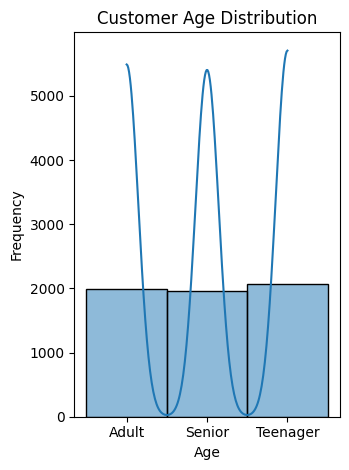

In [17]:
# Age distribution
plt.subplot(1,2,2)
sns.histplot(df['age'], kde=True, bins=20)
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

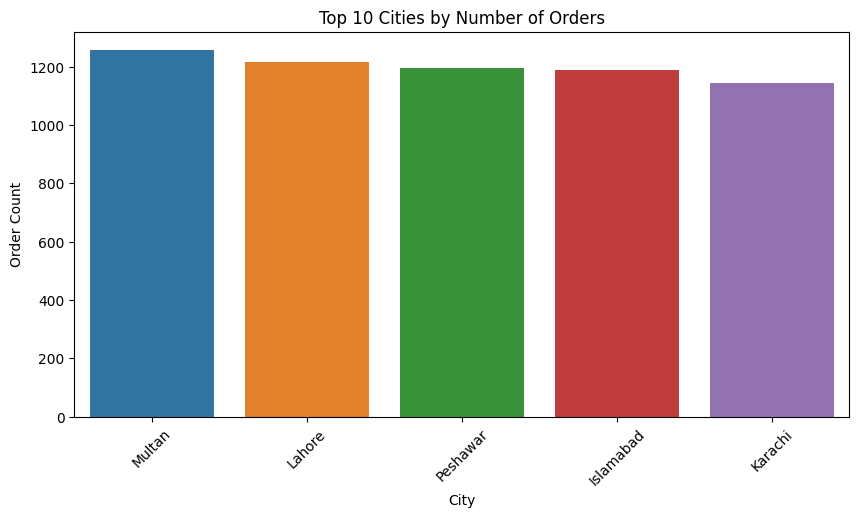

In [18]:
plt.figure(figsize=(10,5))
top_cities = df['city'].value_counts().head(10)
sns.barplot(x=top_cities.index, y=top_cities.values)
plt.title('Top 10 Cities by Number of Orders')
plt.xlabel('City')
plt.ylabel('Order Count')
plt.xticks(rotation=45)
plt.show()

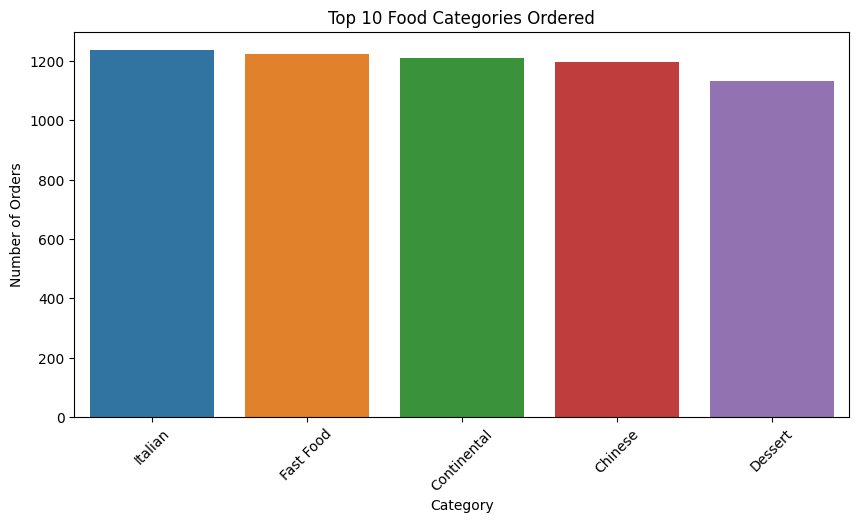

In [19]:
plt.figure(figsize=(10,5))
top_categories = df['category'].value_counts().head(10)
sns.barplot(x=top_categories.index, y=top_categories.values)
plt.title('Top 10 Food Categories Ordered')
plt.xlabel('Category')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

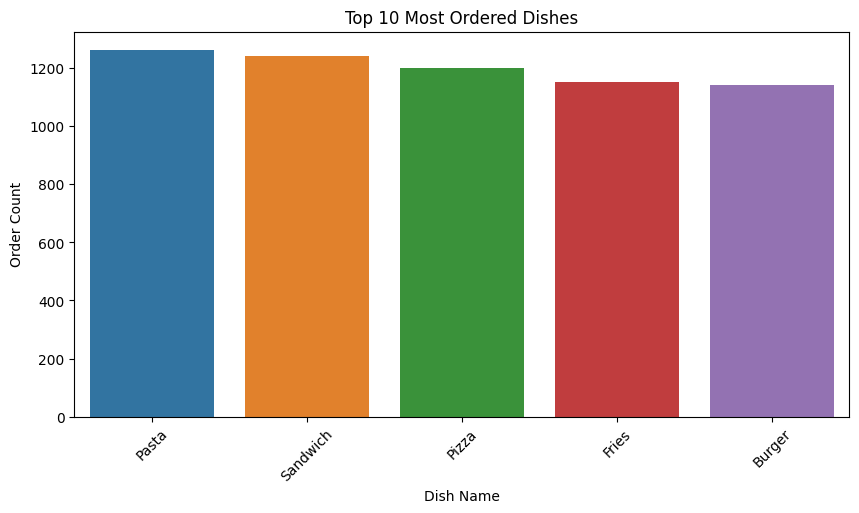

In [20]:
plt.figure(figsize=(10,5))
top_dishes = df['dish_name'].value_counts().head(10)
sns.barplot(x=top_dishes.index, y=top_dishes.values)
plt.title('Top 10 Most Ordered Dishes')
plt.xlabel('Dish Name')
plt.ylabel('Order Count')
plt.xticks(rotation=45)
plt.show()

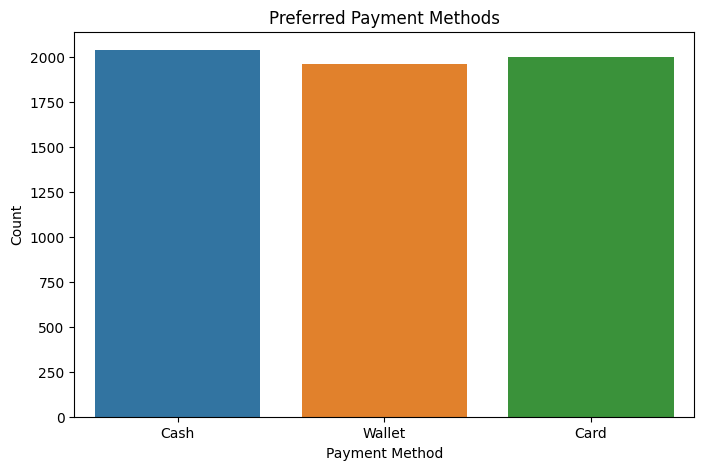

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(x='payment_method', data=df)
plt.title('Preferred Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show()

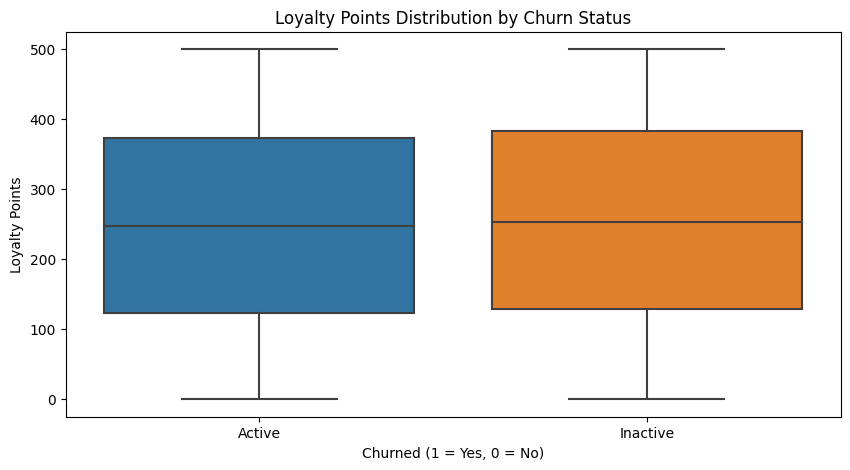

In [22]:
plt.figure(figsize=(10,5))
sns.boxplot(x='churned', y='loyalty_points', data=df)
plt.title('Loyalty Points Distribution by Churn Status')
plt.xlabel('Churned (1 = Yes, 0 = No)')
plt.ylabel('Loyalty Points')
plt.show()


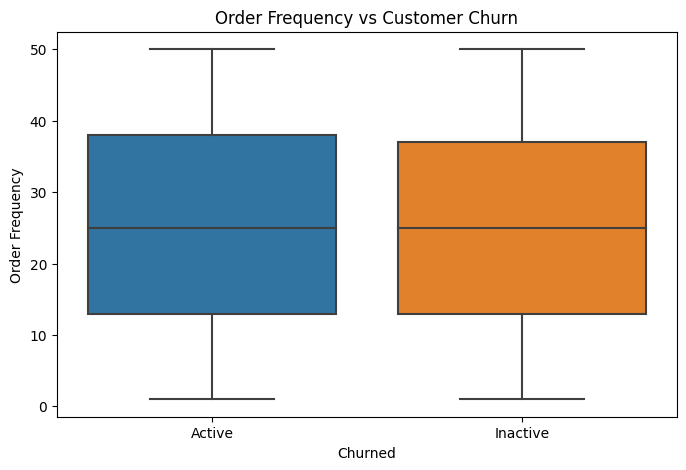

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x='churned', y='order_frequency', data=df)
plt.title('Order Frequency vs Customer Churn')
plt.xlabel('Churned')
plt.ylabel('Order Frequency')
plt.show()

Text(0, 0.5, 'Frequency')

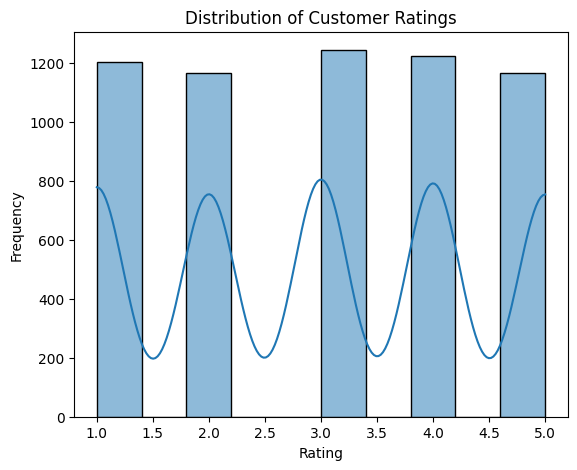

In [24]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.histplot(df['rating'], bins=10, kde=True)
plt.title('Distribution of Customer Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')

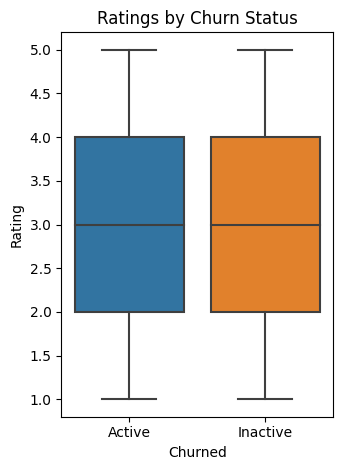

In [25]:
plt.subplot(1,2,2)
sns.boxplot(x='churned', y='rating', data=df)
plt.title('Ratings by Churn Status')
plt.xlabel('Churned')
plt.ylabel('Rating')

plt.tight_layout()
plt.show()

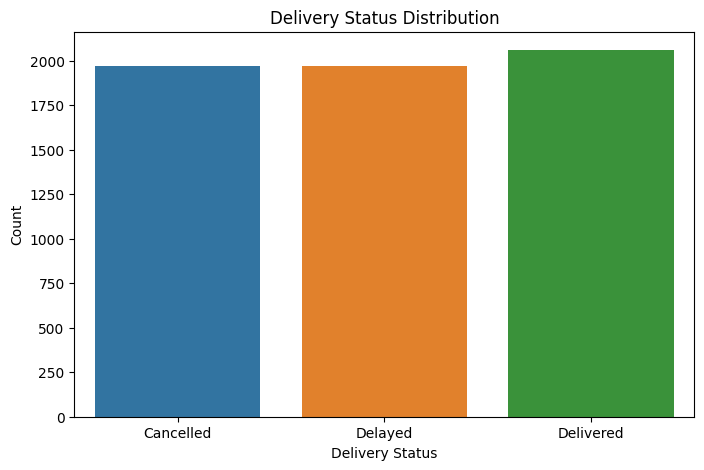

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(x='delivery_status', data=df)
plt.title('Delivery Status Distribution')
plt.xlabel('Delivery Status')
plt.ylabel('Count')
plt.show()

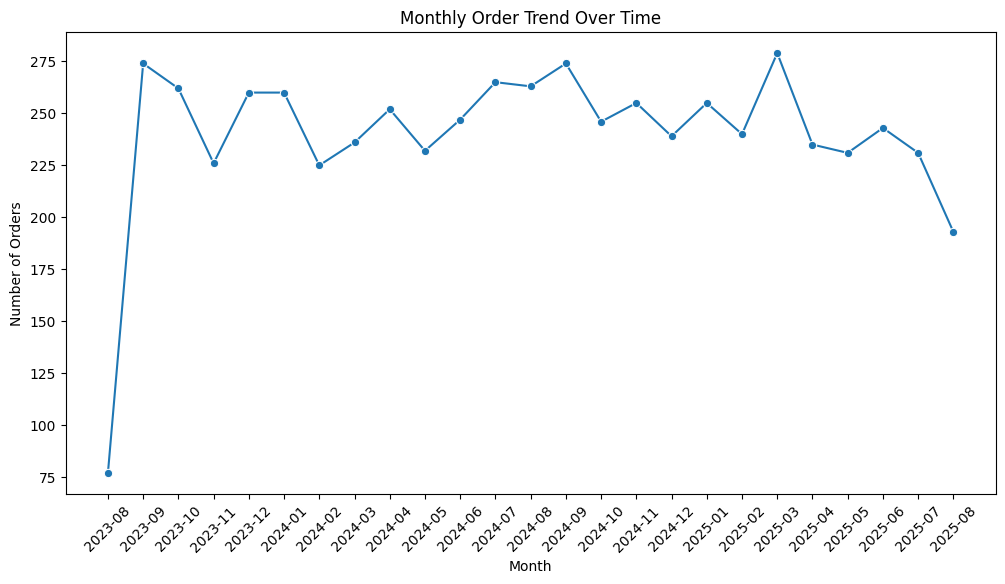

In [27]:
df['order_month'] = df['order_date'].dt.to_period('M').astype(str)

monthly_orders = df['order_month'].value_counts().sort_index()
plt.figure(figsize=(12,6))
sns.lineplot(x=monthly_orders.index, y=monthly_orders.values, marker='o')
plt.title('Monthly Order Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

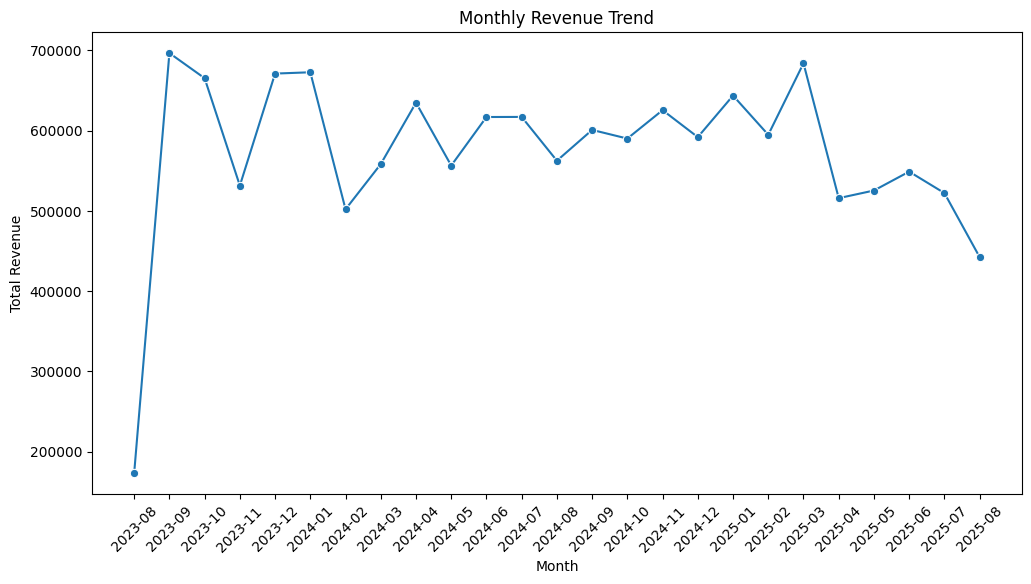

In [28]:
df['total_price'] = df['price'] * df['quantity']
monthly_revenue = df.groupby('order_month')['total_price'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(x='order_month', y='total_price', data=monthly_revenue, marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

## ML Algorithms

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [30]:
drop_cols = ['customer_id', 'order_id', 'signup_date', 'order_date', 
             'last_order_date', 'rating_date', 'restaurant_name', 'dish_name']
df = df.drop(columns=drop_cols, errors='ignore')


In [31]:
df = df.fillna(df.mode().iloc[0])

In [32]:
# 🔠 Label Encoding for categorical columns
label_enc = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = label_enc.fit_transform(df[col])

In [33]:
X = df.drop('churned', axis=1)
y = df['churned']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Support Vector Machine": SVC(),
    "KNN": KNeighborsClassifier()
}

accuracy_results = {}

In [36]:
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    accuracy_results[name] = round(acc, 2)
    print(f"{name} Accuracy: {acc:.2f}%")

Logistic Regression Accuracy: 48.17%
Decision Tree Accuracy: 50.08%
Random Forest Accuracy: 47.42%
Gradient Boosting Accuracy: 48.17%
Support Vector Machine Accuracy: 47.50%
KNN Accuracy: 54.92%


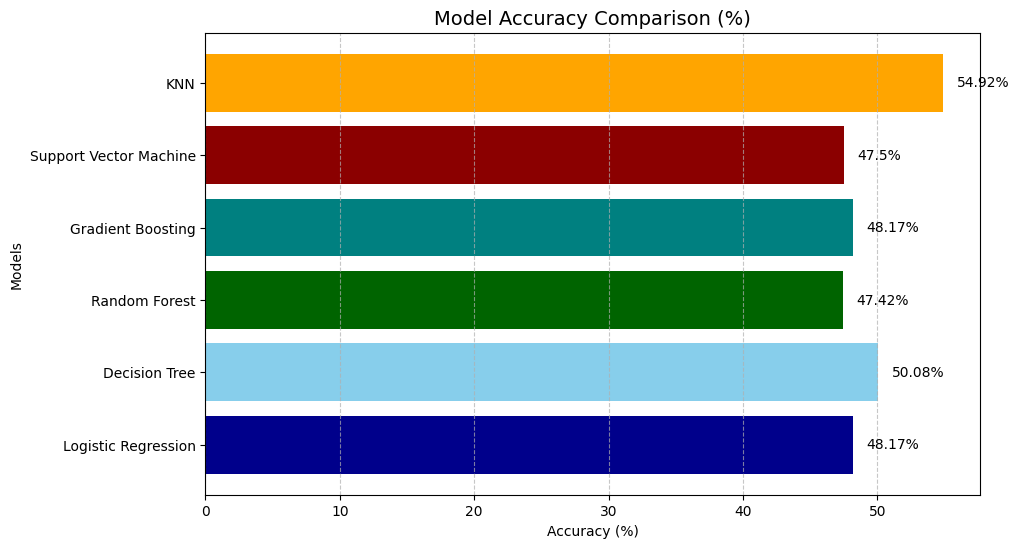

In [37]:
plt.figure(figsize=(10,6))
plt.barh(list(accuracy_results.keys()), list(accuracy_results.values()), color=['darkblue','skyblue','darkgreen','teal','darkred','orange'])
plt.title("Model Accuracy Comparison (%)", fontsize=14)
plt.xlabel("Accuracy (%)")
plt.ylabel("Models")
plt.grid(axis='x', linestyle='--', alpha=0.7)
for i, v in enumerate(accuracy_results.values()):
    plt.text(v + 1, i, f"{v}%", va='center', fontsize=10)
plt.show()

In [38]:
best_model = max(accuracy_results, key=accuracy_results.get)
print(f"\n🏆 Best Performing Model: {best_model} with {accuracy_results[best_model]}% accuracy")


🏆 Best Performing Model: KNN with 54.92% accuracy


## Thank you...pls upvote!!!